In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy import linalg

from tutorial_utils import reliability_diagram, get_mvn_cdf

/home/kleeman/miniconda3/envs/dev/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.2)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


# Definition of Residuals

Consider the situation where you have some measurements, $y_i$, for some inputs, $x_i$, and a model which has attempted to predict the values of the measurements, $\hat{y}_i = \mbox{model}(x_i)$, from which we can compute residuals,
$$
r_i = y_i - \hat{y}_i
$$

Let's assume we're dealing with multi-dimensional data (so $y = \left\{y_0, \ldots, y_n\right\}$) and the measurements may be correlated (so, for example, maybe $y$ represents a series of hourly temperature measurements, $x_i$ would be the hour corresponding to $y_i$. If the measurements are close enough in time that they might be correlated, so the residuals may also be correlated). We can simulate a situation like this by creating a random covariance $\Sigma$ and then drawing random samples from it to serve is simulated residuals,
$$
r \sim \mathcal{N}\left(0, \Sigma\right)
$$

(-3.0, 3.0)

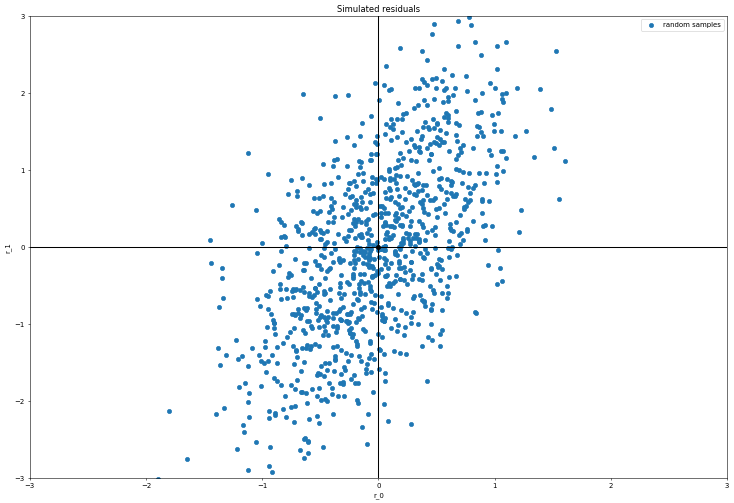

In [159]:
MEAS_NOISE = 1e-2
def random_covariance(n, meas_noise=MEAS_NOISE):
    # make a random orthonormal matrix
    Q, _ = np.linalg.qr(np.random.normal(size=(n, n)))
    # then random "eigen values"
    V = np.random.gamma(shape=1., size=n)
    # and add a little bit of measurement noise,
    noise = meas_noise * meas_noise * np.eye(n)
    return Q @ np.diag(V) @ Q.T + noise


def random_samples(cov, k=1000):
    # returns an (n, k) matrix with random samples such that each
    # column is a sample from N(0, cov)
    return np.random.multivariate_normal(np.zeros(cov.shape[0]), cov, size=k).T

S = random_covariance(2)
samples = random_samples(S, 1000)
plt.scatter(samples[0, :], samples[1, :], label="random samples")
plt.scatter(0, 0, color="black")
plt.plot([-5, 5], [0, 0], color='black')
plt.plot([0, 0], [-5, 5], color='black')
plt.ylabel("r_1")
plt.xlabel("r_0")
plt.title("Simulated residuals")
plt.legend()
plt.xlim([-3, 3])
plt.ylim([-3, 3])

Each point is a randomly generated $r$. The x axis shows $r_0$ for each sample, the y axis shows $r_1$. The scale is fixed there, so if you evaluate it repeatedly you'll see different random distributions.

# Measure of Residuals
Now we'd like to compute some measure of the size of the residuals, probably something like the root mean squared error which (assuming $r \in \mathbb{R}^{n}$ is a vector) could be computed,
$$
\mbox{rmse}(r) = \sqrt{\frac{1}{n} r^T r}
$$
or perhaps mean absolute error,
$$
\mbox{mae}(r) = \frac{1}{n}\sum_i |r_i|
$$
using the simulated values above we can look at the distribution of expected RMSEs,

Text(0.5, 1.0, 'Simulated Root Mean Squared Errors')

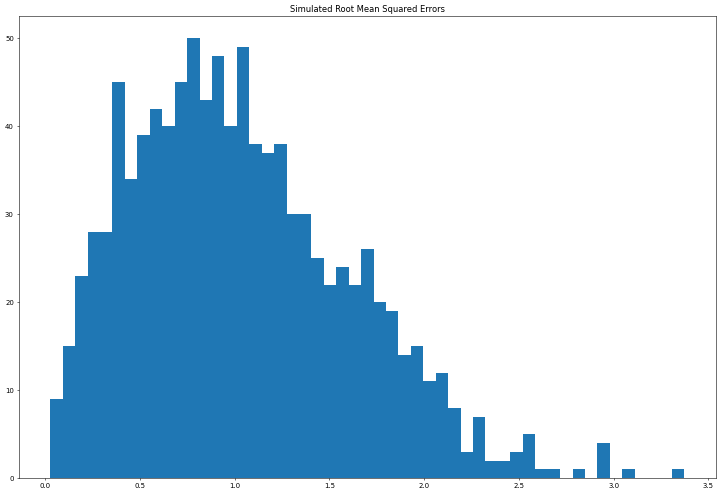

In [140]:
def rmse(x):
    return np.sqrt(np.mean(np.square(x), axis=0))

plt.hist(rmse(samples), bins=51)
plt.title("Simulated Root Mean Squared Errors")

The root mean squared error is a popular choice for measuring accuracy of a model because _under the assumption the residuals are unbiased_ the expected RMSE should tend towards zero when the model makes perfect predictions. In practice however, there may be reasons you'd never expect the RMSE to approach zero. If the residuals are computed using measurements and those measurements have measurement noise, then even a "perfect" model will not be able to know the measurement noise for an out of sample measurement. Similarly, there may be other unmodelable quantities which would prevent the RMSE from approaching zero.

# Unmodelable Bias

Now say that there exist biases in the actual measurements which are unmodelable. Maybe we're trying to model temperature at some location over a period of time but the "truth" measurements are from a low quality thermometer  which may not have been well calibrated. While we'd hope the model is capable of predicting temperature perfectly, there's no reason to expect the temperature model to know the calibration bias for an out of sample thermometer. We could then call the calibration bias unmodelable.

Here's a visualization of what a calibration bias might look like,

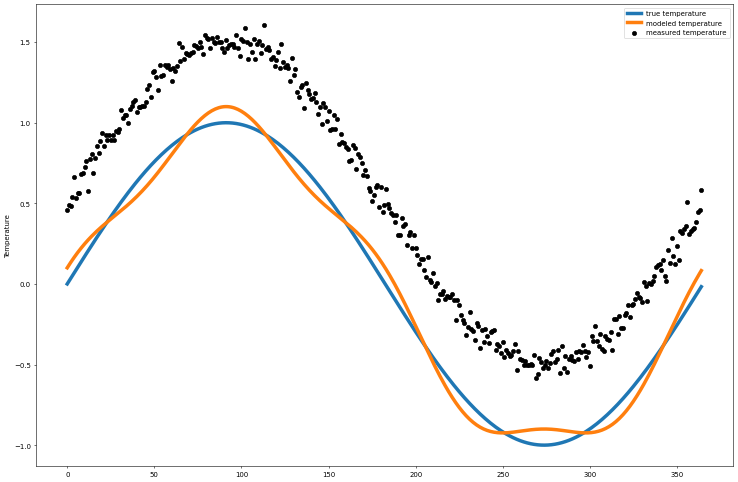

In [141]:
xs = np.arange(365)
seasonality = xs * (2 * np.pi / 365)
truth = np.sin(seasonality)
plt.plot(xs, truth, label="true temperature", lw=5)
modeled = truth + 0.1 * np.cos(seasonality * 4)
plt.plot(xs, modeled, label="modeled temperature", lw=5)
measurements = truth + 0.5 + 0.05 * np.random.normal(size=truth.size)
plt.scatter(xs, measurements, label="measured temperature", color='black')
plt.ylabel("Temperature")
plt.legend()

If we were to directly compute the residuals we'd see a very obvious bias:

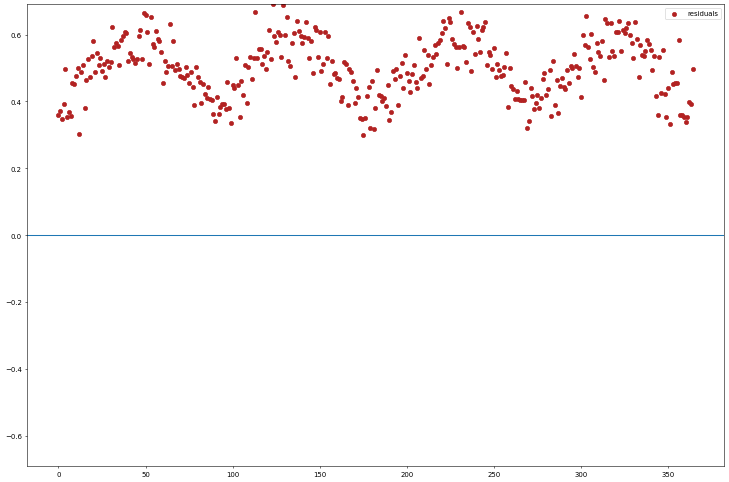

In [142]:
residuals = measurements - modeled
plt.scatter(xs, residuals, label="residuals", color='firebrick')
lim = np.max(np.abs(residuals))
plt.ylim([-lim, lim])
xlim = plt.xlim()
plt.plot(xlim, [0, 0])
plt.xlim(xlim)
plt.legend()

In this case we probably don't actually care about the raw residuals, $r = y - \hat{y}$ since we know it's contaminated by something unmodelable. Instead we might want to allow for a constant offset. There are (at least) two ways this could be accomplished. You can imagine removing the mean residual, which we'll call "debiasing",

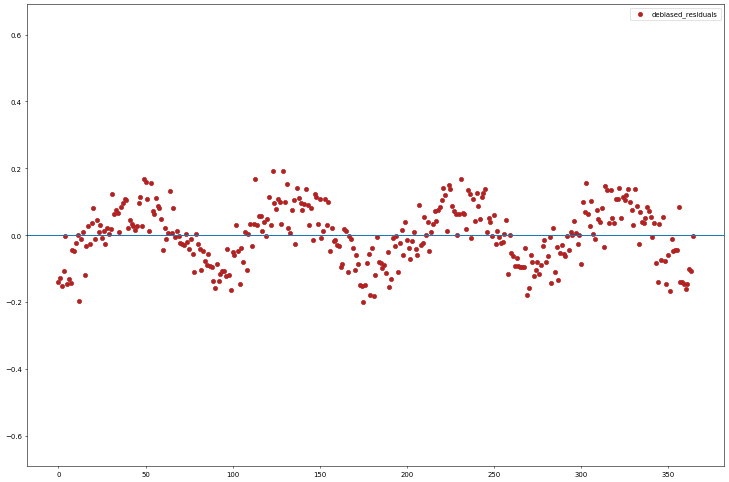

In [143]:
plt.scatter(xs, residuals - np.mean(residuals), label="debiased_residuals", color='firebrick')
lim = np.max(np.abs(residuals))
plt.ylim([-lim, lim])
xlim = plt.xlim()
plt.plot(xlim, [0, 0])
plt.xlim(xlim)
plt.legend()

But another technique which is relatively common in some domains is to compute the difference between residuals. To do so you'd need to pick a reference and subtract it from all other elements,

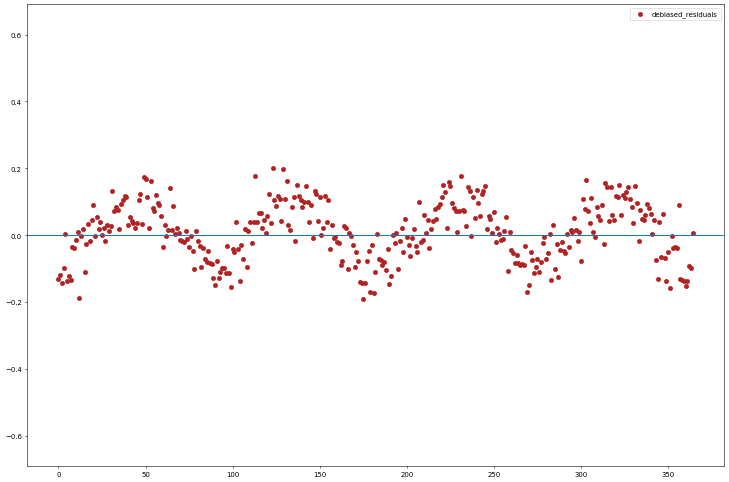

In [144]:
plt.scatter(xs, residuals - residuals[25], label="debiased_residuals", color='firebrick')
lim = np.max(np.abs(residuals))
plt.ylim([-lim, lim])
xlim = plt.xlim()
plt.plot(xlim, [0, 0])
plt.xlim(xlim)
plt.legend()

Assuming the unmodelled bias was the same on all residuals, then differencing will cancel the bias. Here are the RMSEs we would get using these two different approaches (debiasing and differencing):

In [145]:
print("RMSE[debias]", rmse(residuals - np.mean(residuals)))
print("RMSE[differencing]", rmse(residuals - residuals[25]))

RMSE[debias] 0.08479591630520096
RMSE[differencing] 0.08522232104624593


Both methods remove the bias, but notice that the two approaches are NOT the same! As you can imagine, the differenced RMSE will be sensitive to the choice of reference.

# Simulations With Bias

Let's generate some more simulations with biases to explore the pros/cons of these two approaches for measuring residuals in the presence of a bias.

(-5.0, 5.0)

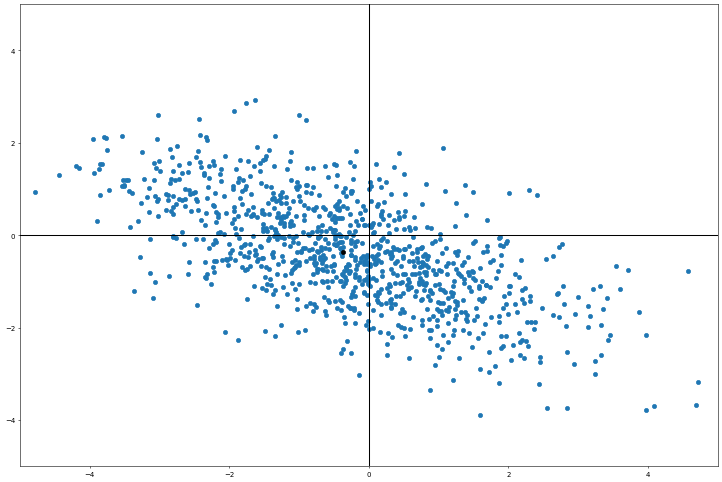

In [147]:
S = random_covariance(2)
bias = np.random.normal(size=1)
samples = random_samples(S, 1000) + bias
plt.scatter(samples[0, :], samples[1, :])
plt.scatter(bias, bias, color="black")
plt.plot([-5, 5], [0, 0], color='black')
plt.plot([0, 0], [-5, 5], color='black')
plt.xlim([-5, 5])
plt.ylim([-5, 5])

If you re evaluate the previous cell enough you should see that we now have random samples which are all offset by another random value. Now, we can make some operators which do the equivalent of removing a mean, or picking a reference. First consider the differencing operator,
$$
D = \begin{bmatrix}
1 & 0 & \cdots & 0 & -1 \\
0 & 1 & \cdots & 0 & -1 \\
\vdots & \vdots & \vdots & \vdots & \vdots \\
0 & 0 & \cdots & 1 & -1 \\
    \end{bmatrix}
$$
The result of this operator will be a new vector, $D r \in \mathbb{R}^{n-1}$ with elements corresponding to having subtracted off the last (reference) residual $\left[Dr\right]_i = r_i - r_n$

In [148]:
def diff_operator(n):
    # return an (n-1, n) matrix in the form:
    #
    #   [1 0 ... 0 -1]
    #   [0 1 ... 0 -1]
    #   [0 0 ... 1 -1]
    #
    # which represents using the last element as reference
    # in a differencing operation.
    D = np.eye(n-1, n)
    D[:, -1] = -1
    return D

Similarly we can form a debias operator which removes the mean value. This operator will look something like,
$$
B = I - \frac{1}{n} \mathbb{1}^{n, n}
$$
The result will be a new vector $B r \in \mathbb{R}^{n}$ with elements corresponding to having subtracted off the mean residual $\left[Br\right]_i = r_i - \frac{1}{n}\sum_j r_j$.

In [149]:
def debias_operator(n):
    # return an (n, n) matrix in the form:
    #
    #   [1-a   -a ... -a]
    #   [-a   1-a ... -a]
    #   [-a   -a  ... 1-a]
    #
    # which represents solving for a bias, b, which solves
    # the least squares solution to,
    #
    #   y = A x
    #
    # with A and x looking like
    #
    #       |1
    #   y = |1  x
    #       |.
    #       |1
    return np.eye(n) - (1.0 / n) * np.ones((n, n))

Now let's use these operators to compute the RMSE of residuals for a large number of random simulations. Because it's a simulation we know the bias we've added to the residuals, so we can compute the "actual" (uncontaminated) residuals and compare the RMSE we'd get with debiasing or differencing to the residuals we would have gotten if the truth were not biased.

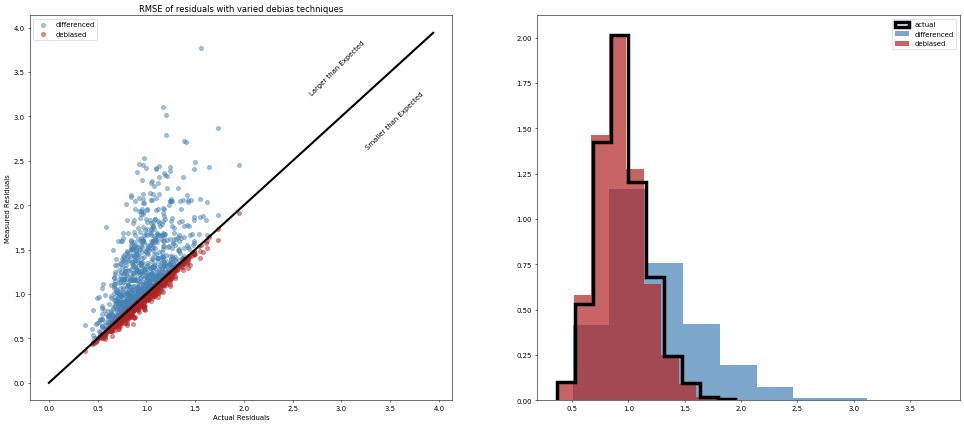

In [150]:
def random_simulation(n=100, k=1000):
    S = random_covariance(n)
    bias = np.random.normal(size=1)
    r = random_samples(S, k) + bias
    return S, bias, r

def compare_rmses(residuals, known_bias, label=None):
        D = diff_operator(S.shape[0])
        diff_residuals = D @ residuals
        diff_rmses = rmse(diff_residuals)

        B = debias_operator(S.shape[0])
        debias_residuals = B @ residuals
        debias_rmses = rmse(debias_residuals)

        actual_rmses = rmse(r - known_bias)

        fig, axes = plt.subplots(1, 2, figsize=(24, 10))

        axes[0].scatter(actual_rmses, diff_rmses, color='steelblue',
                        alpha=0.5, label="differenced")
        axes[0].scatter(actual_rmses, debias_rmses, color='firebrick',
                        alpha=0.5, label="debiased")
        ylim = max(axes[0].get_ylim())
        axes[0].plot([0, ylim], [0, ylim], color='black', lw=3)
        axes[0].set_xlabel("Actual Residuals")
        axes[0].set_ylabel("Measured Residuals")
        axes[0].legend()
        axes[0].set_title("RMSE of residuals with varied debias techniques")
        
        axes[0].text(0.75 * ylim, 0.9 * ylim, "Larger than Expected",
                     horizontalalignment="center",
                     verticalalignment="center",
                     rotation=45)
        axes[0].text(0.9 * ylim, 0.75 * ylim, "Smaller than Expected",
                     horizontalalignment="center",
                     verticalalignment="center",
                     rotation=45)
        axes[1].hist(actual_rmses, color='black', label="actual",
                     histtype='step', density=True, lw=5)
        axes[1].hist(diff_rmses, color='steelblue', label="differenced",
                     density=True, alpha=0.7)
        axes[1].hist(debias_rmses, color='firebrick', label="debiased",
                     density=True, alpha=0.7)
        axes[1].legend()

S, bias, r = random_simulation(n=20, k=1000)
compare_rmses(r, bias)

The differenced residuals are typically larger than we'd expect while the debiased residuals are typically smaller! Looking at the histograms we see the debiased residuals align much more closely with the "actual" residuals (which were computed using the known bias).

Why? By differencing, any measurement noise from the reference measurement is going to get added into all the other residuals, which is then going to get squared before summing. Sometimes that aded measurement noise might actually cancel other noise, so you'll occasionally see some differenced residuals which are smaller than expected, but typically that added noise will increase residuals.

On the contrary, when you debias some of the measurement noise is going to influence your estimate of the bias, so when the bias is removed from the measurements it'll also be removing the average measurement noise, making the RMSE values smaller. When debiasing this phenomena diminishes with more observations (more observations means it's more likely the average noise is zero). With differencing the pheonoema persists, here's the same plot when you increase the number of measurements in each sample,

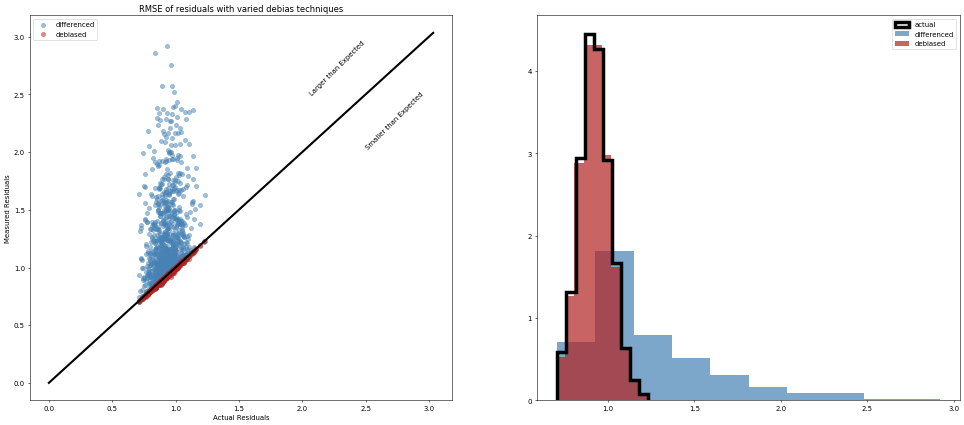

In [151]:
S, bias, r = random_simulation(n=100, k=1000)
compare_rmses(r, bias)

The key point here: in the limit (so as you include more measurements in your residual computations) the RMSE you'd compute using a debiasing technique will approach the RMSE you'd get if you'd known the actual bias. If you're differencing that will not be the case, your RMSE computing when differencing will always be heavily influenced by a single measurement's noise.

# With Outliers

Consider what would happen if the data were contaminated with an outlier. Here's what would happen to our residual distributions in the presence of a single outlier added to the first residual,

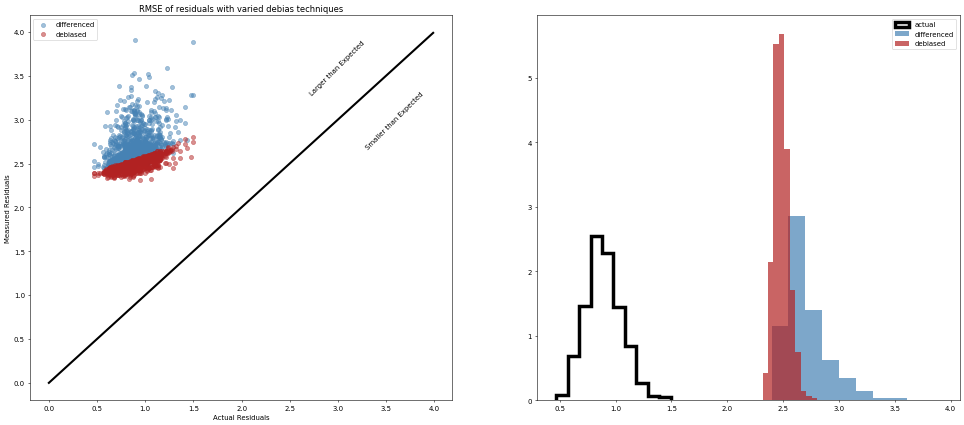

In [152]:
S, bias, r = random_simulation(n=20, k=1000)

perturbed = r.copy()
perturbed[0] = 10.
compare_rmses(perturbed, bias)
plt.legend()

That outlier contaminated both the debiasing approach and the differencing approach which both got shifted by approximately the same amount. Of course, if that outlier happened to also be the reference residuals (last one in this simulation) then we can see the two approaches do NOT respond the same,

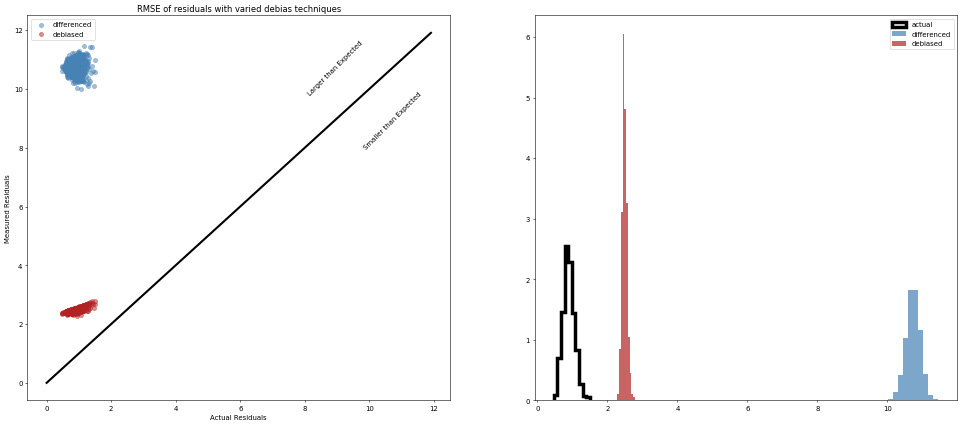

In [153]:
perturbed = r.copy()
perturbed[-1] = 10.
compare_rmses(perturbed, bias)
plt.legend()

We can see that both approaches are sensitive to outliers, but the differencing approach will completely fall apart if the outlier happened to be picked as reference.

Key point: differencing approaches are much more susceptible to outliers

## Reliability Diagrams with Biased Data

Looping back to the simulations with biased data, can we still use reliability diagrams after we've manipulated the residuals to remove a constant bias? The answer is yes: though we need to also be sure to manipulate the covariance. Take the differencing approach from above. We started with some residuals $r$ and computed a differencing operator $D$ to get the differenced residuals $D r$. If we think that,
$$
\mathbf{r} \sim \mathcal{N}(b, \Sigma)
$$
Then we can get the differenced distribution,
$$
D \mathbf{r} \sim \mathcal{N}(0, D \Sigma D^T)
$$
So we can first apply the operator to both the residuals and the covariance, then compute a reliability diagram,

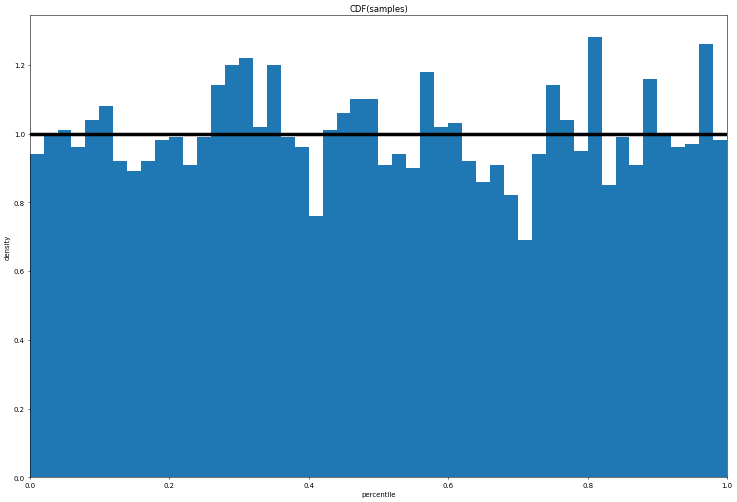

In [154]:
S, bias, r = random_simulation(n=10, k=5000)

D = diff_operator(S.shape[0])
diff_residuals = D @ r
diff_cov = D @ S @ D.T

reliability_diagram(diff_residuals, get_mvn_cdf(diff_cov))

Yep! looks like if the predicted covariance $\Sigma$ was reliable, then the differenced covariance is also reliable. Let's try the same thing with the debiasing operator,

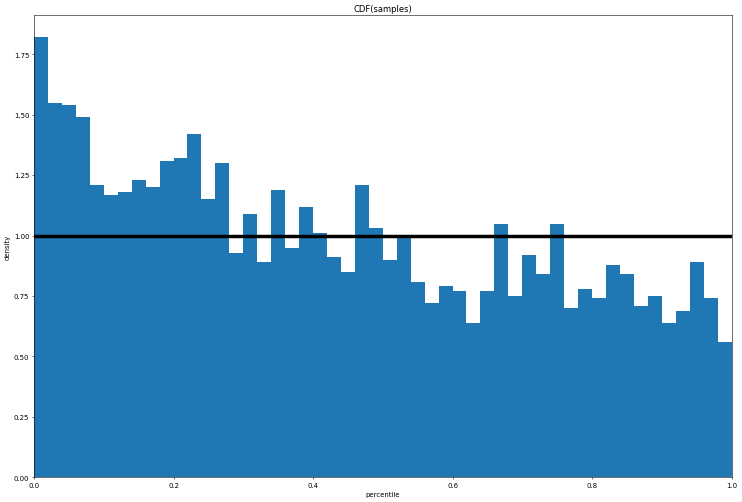

In [155]:
B = debias_operator(S.shape[0])

debias_residuals = B @ r
debias_cov = B @ S @ B.T

reliability_diagram(debias_residuals, get_mvn_cdf(debias_cov))

Uh Oh. The result shoudln't look perfectly uniform. Why? Check out the sizes of the operators for the two approaches:

In [156]:
print("Difference", D.shape)
print("Debias", B.shape)

Difference (9, 10)
Debias (10, 10)


The difference operator removes a dimension, the debias operator does not. So when we compute the normalized sum square error while differencing we assume it's chi squared distributed with $n$ degrees of freedom, but when we do the same for the debias approach we're using $n-1$ degrees of freedom. Here's the reliability diagram for the debias approach (again) but this time with one fewer degrees of freedom:

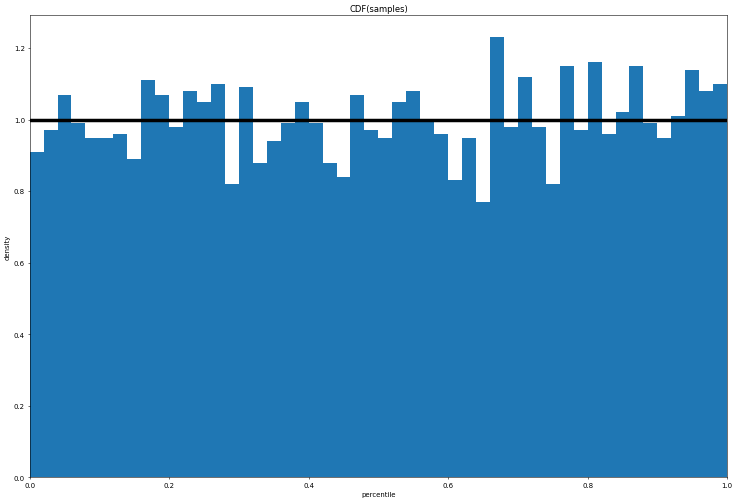

In [127]:
debias_df = debias_cov.shape[0] - 1
reliability_diagram(debias_residuals, get_mvn_cdf(debias_cov, df=debias_df))

Much better. So if we're using the debias operator we need to remove a degree of freedom, but what about other operators?

# General Least Squares Operators
Above the debias operator was hard coded specifically such that the resulting residuals will have had the mean value removed $r_i = r_i - \frac{1}{n} \sum_j^n r_j$. Another way to think about this is that we're estimating a common bias, which can be framed as a least squares problem. We can say that we'd like to estimate a term, $x$, which is shared with all residuals. We can write this,
$$
r = A x
$$
with
$$
A = \begin{bmatrix}
1 \\ \vdots \\ 1
\end{bmatrix}
$$
and
$$
x = \begin{bmatrix} \mbox{bias} \end{bmatrix}
$$
we can find the least squares solution for $x$ using the normal equations,
$$
x = \left(A^T A\right)^{-1} A^T r
$$
and because that represents our bias, we can then remove it from the residuals,
$$
\begin{align}
\hat{r} &= r - A x \\
&= r - A \left(A^T A\right)^{-1} A^T r \\
&= r - H r \\
&= \left(I - H\right) r
\end{align}
$$
The $H = A \left(A^T A\right)^{-1} A^T$ term is often called the "hat operator" and it has some cool properties (which I've stolen from [here](https://stats.stackexchange.com/a/24941)). First, $H$ is symmetric, so $H = H^T$. Also $H$ is idempotent, so applying it once is the same as applying it repeatedly $H H = H$. For this to hold that means that $H$ must have eigen values which are either zero or one and we can take advantage of that to determine how many degrees of freedom are being removed when we apply these operators. Here is the hat operator for our debiasing example,

In [128]:
def hat_operator(A):
    # H = A (A^T A)^-1 A^T
    return A @ np.linalg.solve(A.T @ A, A.T)

A_debias = np.ones((4, 1))
H = hat_operator(A_debias)
print("Hat Operator: \n", H)
print("Eigenvalues: ", np.linalg.eigvals(H))

Hat Operator: 
 [[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]
Eigenvalues:  [0. 1. 0. 0.]


From this we see that there is one non-zero eigen value, so we must be removing one degree of freedom. We can use the hat operator to form the debiasing operator ($I - H$),

In [129]:
def debias_operator_alternate(n):
    A = np.ones((n, 1))
    return np.eye(n) - hat_operator(A)

print("Via Least Squares\n", debias_operator_alternate(4))
print("Hardcoded\n", debias_operator(4))

Via Least Squares
 [[ 0.75 -0.25 -0.25 -0.25]
 [-0.25  0.75 -0.25 -0.25]
 [-0.25 -0.25  0.75 -0.25]
 [-0.25 -0.25 -0.25  0.75]]
Hardcoded
 [[ 0.75 -0.25 -0.25 -0.25]
 [-0.25  0.75 -0.25 -0.25]
 [-0.25 -0.25  0.75 -0.25]
 [-0.25 -0.25 -0.25  0.75]]


We now have the tools to start with a proposed residual distribution, $r \sim \mathcal{N}(\mu, \Sigma)$, from which we'd like to remove some unmodelable terms. We can describe the terms we'd like to remove using a least squares approach, $A$, use $A$ to remove the unmodeled terms, and manipulate the covariance in a way which let's us still test the reliability of the original uncertainty estimate. What if, for example, we actually think there's a linear trend in the residuals which we would like to remove,

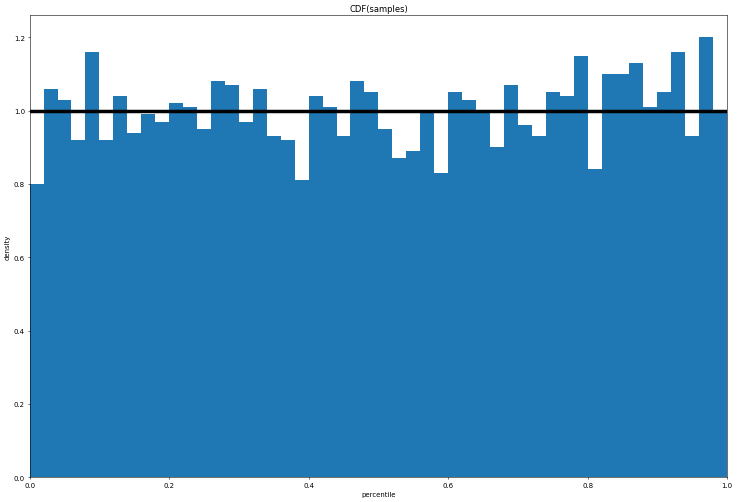

In [130]:
n = S.shape[0]
A_linear = np.vander(np.arange(n), 2)
H = hat_operator(A_linear)
B = np.eye(n) - H

detrended_residuals = B @ r
detrended_cov = B @ S @ B.T
detrended_df = np.trace(B) # trace = sum of eigen values
reliability_diagram(detrended_residuals, get_mvn_cdf(detrended_cov, df=detrended_df))

Still looks reliable. In this case removing a linear trend was overkill, but the process still works. Even if you've removed more than you need to and subsequently computed residuals, you can still check if the uncertainty is reliable. (Though just because it's reliable after removing a linear trend doesn't mean it's reliable with only a constant bias)

# Gaussian Process Operators
Recall that fitting a Gaussian process involves first prescribing a covariance function. You then evaluate the covariance function between all data points to get the prior covariance,
$$
\mathbf{y} \sim \mathcal{N}\left(0, K_{ff} + \sigma^2 I\right)
$$
where $[K_{ff}]_{ij} = \mbox{cov}(x_i, x_j)$. Making a prediction of the mean for a GP at some new locations, $x_*$ then requires forming $K_{*f}$ and computing,
$$
y_* =K_{*f} \left(K_{ff} + \sigma^2 I\right)^{-1} y
$$
So, if we want to compute residuals from a Gaussian process, we'd just make prediction for the same locations we had measurements (being sure not to include measurement noise). That gives us,
$$
\hat{y} = K_{ff} \left(K_{ff} + \sigma^2 I\right)^{-1} y
$$
From this we can see that the equivalent "hat operator" for a GP is:
$$
H = K_{ff} \left(K_{ff} + \sigma^2 I\right)^{-1}
$$

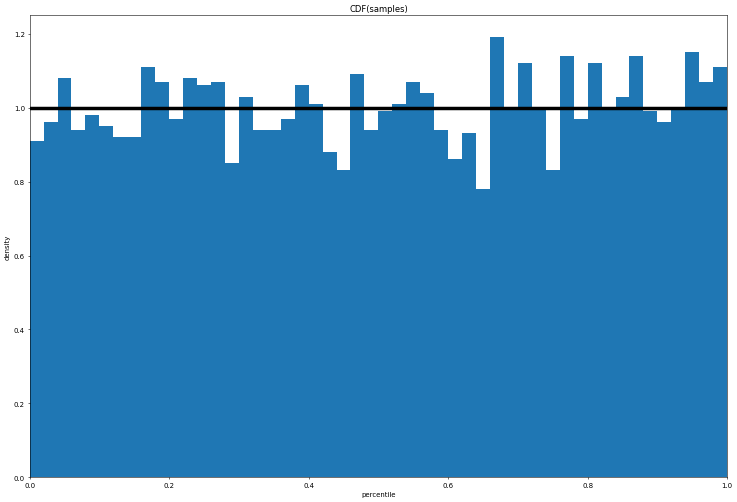

In [132]:
n = S.shape[0]
K_ff = 100 * np.ones((n, n)) # allow for a relatively large constant offset
H = np.linalg.solve(K_ff + MEAS_NOISE * MEAS_NOISE * np.eye(n), K_ff)
G = np.eye(n) - H

gp_df = np.trace(G)
gp_residuals = G @ r
gp_cov = G @ S @ G.T

reliability_diagram(gp_residuals, get_mvn_cdf(gp_cov, df=gp_df))